In [1]:
!pip install -q timm lime shap scikit-image opencv-python-headless seaborn tqdm

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 7.2 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done


In [5]:
import os, glob, random, time, json, hashlib, copy, warnings, zipfile, shutil
warnings.filterwarnings("ignore")
import numpy as np, pandas as pd, cv2
import matplotlib.pyplot as plt, seaborn as sns
from tqdm.auto import tqdm
from IPython.display import display
import torch, torch.nn as nn, torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import timm
from skimage.restoration import denoise_tv_chambolle
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.metrics import (accuracy_score, precision_recall_fscore_support, classification_report,
                             confusion_matrix, roc_curve, auc, roc_auc_score, f1_score)
from sklearn.preprocessing import label_binarize

# ------------------------- configuration -------------------------
SEED        = 42
IMG_SIZE    = 224
BATCH       = 16
CLASSES     = ["benign", "malignant", "normal"]
CLASS2IDX   = {c: i for i, c in enumerate(CLASSES)}
SEG_EPOCHS  = 40
CLS_EPOCHS  = 30
PATIENCE    = 7
BG_FLOOR    = 0.5      # background intensity kept when the OAST lesion map is used to emphasise the lesion

RUN_OOA     = True     # set False to skip tuning and use default hyper-parameters
OOA_POP, OOA_ITERS, OOA_PROXY_EPOCHS = 5, 3, 3
RUN_CV      = False    # 10-fold CV is slow (~30+ min on a T4); switch on when needed
CV_EPOCHS   = 8

# ------------------------- Google Drive -------------------------
from google.colab import drive
drive.mount("/content/drive")
DRIVE_ROOT = "/content/drive/MyDrive/priya dharshini/datasetA"      # folder that contains benign / malignant / normal
DRIVE_ROOT1 = "/content/drive/MyDrive/priya dharshini"      # folder
OUT_DIR = f"{DRIVE_ROOT1}/results_datasetA"                  # results are saved back to Drive so they persist
os.makedirs(OUT_DIR, exist_ok=True)
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
AMP = DEVICE == "cuda"

def set_seed(s=SEED):
    random.seed(s); np.random.seed(s); torch.manual_seed(s); torch.cuda.manual_seed_all(s)
set_seed()
results = {}
print("Device:", DEVICE, "| torch", torch.__version__, "| timm", timm.__version__)
if DEVICE == "cpu":
    print("WARNING: no GPU detected – training will be very slow.")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Device: cpu | torch 2.11.0+cpu | timm 1.0.30


## 1. Load Dataset A and split (before preprocessing)

In [6]:
from google.colab import drive
drive.mount("/content/drive")
import os
print(os.listdir("/content/drive/MyDrive/priya dharshini"))

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
['results_datasetA', 'datasetA', 'main.ipynb']


In [7]:
# Copy the dataset from Drive to the Colab disk once (reading thousands of files straight from Drive is very slow)
LOCAL_ROOT = "/content/busi_local"
for c in CLASSES:
    src = os.path.join(DRIVE_ROOT, c)
    assert os.path.isdir(src), f"Folder not found: {src}  -> check DRIVE_ROOT and the sub-folder names"
    if not os.path.exists(os.path.join(LOCAL_ROOT, c)):
        shutil.copytree(src, os.path.join(LOCAL_ROOT, c))
    print(f"{c:10s}: {len(os.listdir(os.path.join(LOCAL_ROOT, c)))} files")
root = LOCAL_ROOT

imgs, masks = {}, {}
for p in glob.glob(os.path.join(root, "**", "*.*"), recursive=True):
    if not p.lower().endswith((".png", ".jpg", ".jpeg")):
        continue
    cls = os.path.basename(os.path.dirname(p)).lower()
    if cls not in CLASS2IDX:
        continue
    name = os.path.splitext(os.path.basename(p))[0]
    if "_mask" in name:
        masks.setdefault((cls, name.split("_mask")[0]), []).append(p)   # some images have >1 mask
    else:
        imgs[(cls, name)] = p

rows = []
for (cls, name), p in imgs.items():
    rows.append(dict(image_path=p, mask_paths=sorted(masks.get((cls, name), [])), cls=cls, label=CLASS2IDX[cls]))
df = pd.DataFrame(rows).sort_values("image_path").reset_index(drop=True)
print(f"Total images: {len(df)}")
print(df.cls.value_counts().to_string())
print("Images without any mask file:", (df.mask_paths.str.len() == 0).sum(), "(expected: normal images are mask-empty / blank mask)")

benign    : 891 files
malignant : 421 files
normal    : 266 files
Total images: 780
cls
benign       437
malignant    210
normal       133
Images without any mask file: 0 (expected: normal images are mask-empty / blank mask)


In [8]:
# Near-duplicate diagnostic (cheap 16x16 hash) – done BEFORE splitting, only reported, nothing is removed
def img_hash(p):
    g = cv2.imread(p, cv2.IMREAD_GRAYSCALE)
    g = cv2.resize(g, (16, 16), interpolation=cv2.INTER_AREA)
    return hashlib.md5(g.tobytes()).hexdigest()
df["hash"] = [img_hash(p) for p in tqdm(df.image_path, desc="hashing")]

# Stratified image-level split 70 / 15 / 15
train_df, tmp_df = train_test_split(df, test_size=0.30, stratify=df.label, random_state=SEED)
val_df, test_df  = train_test_split(tmp_df, test_size=0.50, stratify=tmp_df.label, random_state=SEED)
df["split"] = "train"
df.loc[val_df.index, "split"] = "val"
df.loc[test_df.index, "split"] = "test"

tab = pd.crosstab(df.cls, df.split)[["train", "val", "test"]]
tab["total"] = tab.sum(1)
tab.loc["Total"] = tab.sum()
tab.columns = ["Training", "Validation", "Testing", "Total"]
print("\nClass distribution (Table 2 equivalent, generated from the actual split):")
display(tab[["Total", "Training", "Validation", "Testing"]])
tab.to_csv(f"{OUT_DIR}/table_class_distribution.csv")

n_cross = int((df.groupby("hash").split.nunique() > 1).sum())
print(f"Near-duplicate groups spanning more than one split: {n_cross}  "
      f"(possible image-level leakage – patient IDs are not available in this dataset)")
results["split_counts"] = tab.to_dict()
results["near_duplicate_groups_across_splits"] = n_cross

hashing:   0%|          | 0/780 [00:00<?, ?it/s]


Class distribution (Table 2 equivalent, generated from the actual split):


,Total,Training,Validation,Testing
cls,,,,
benign,437,306,65,66
malignant,210,147,32,31
normal,133,93,20,20
Total,780,546,117,117


Near-duplicate groups spanning more than one split: 1  (possible image-level leakage – patient IDs are not available in this dataset)


## 2. TVGCF preprocessing

preprocess train:   0%|          | 0/546 [00:00<?, ?it/s]

preprocess val:   0%|          | 0/117 [00:00<?, ?it/s]

preprocess test:   0%|          | 0/117 [00:00<?, ?it/s]

(546, 224, 224, 3) (117, 224, 224, 3) (117, 224, 224, 3)


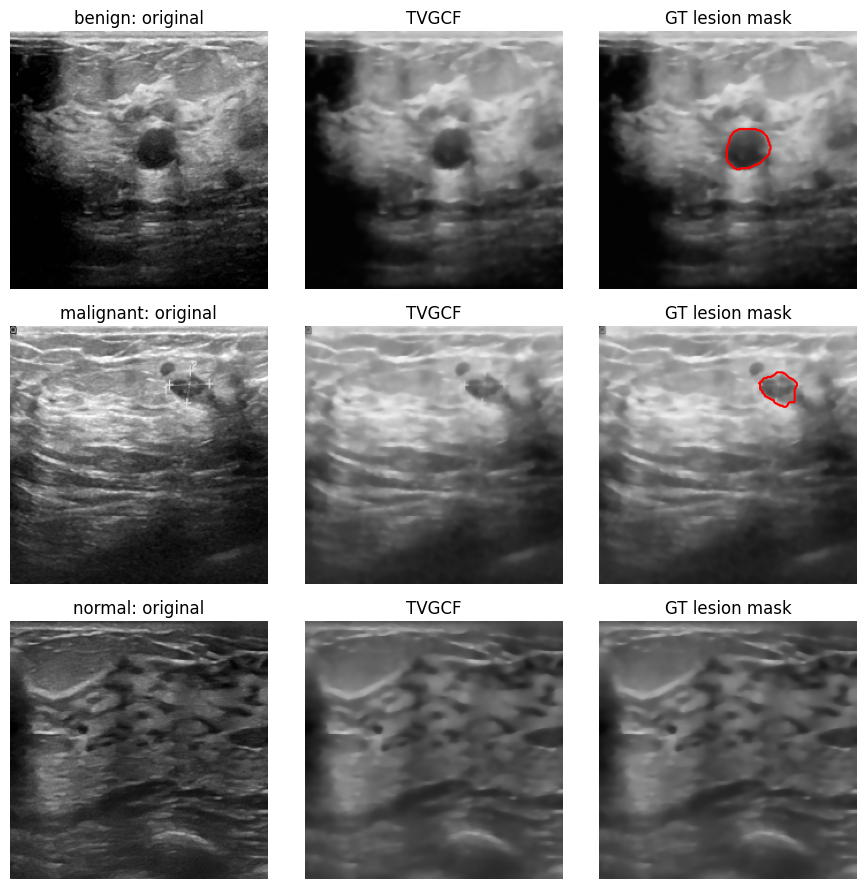

In [9]:
def tvgcf(gray_u8, tv_weight=0.1, gamma=0.8):
    g = gray_u8.astype(np.float32) / 255.0
    den = denoise_tv_chambolle(g, weight=tv_weight)
    out = np.power(np.clip(den, 0, 1), gamma)
    return (out * 255).astype(np.uint8)

def load_sample(img_path, mask_paths, apply_tvgcf=True):
    g = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
    g = cv2.resize(g, (IMG_SIZE, IMG_SIZE), interpolation=cv2.INTER_AREA)
    if apply_tvgcf:
        g = tvgcf(g)
    rgb = np.stack([g] * 3, -1)
    m = np.zeros((IMG_SIZE, IMG_SIZE), np.uint8)
    for mp in mask_paths:                              # union of all lesion masks of the image
        mm = cv2.imread(mp, cv2.IMREAD_GRAYSCALE)
        mm = cv2.resize(mm, (IMG_SIZE, IMG_SIZE), interpolation=cv2.INTER_NEAREST)
        m = np.maximum(m, (mm > 127).astype(np.uint8))
    return rgb, m

def build_subset(sub_df, name):
    X, M = [], []
    for r in tqdm(sub_df.itertuples(), total=len(sub_df), desc=f"preprocess {name}"):
        x, m = load_sample(r.image_path, r.mask_paths)
        X.append(x); M.append(m)
    return np.stack(X), np.stack(M), sub_df.label.values.astype(np.int64)

Xtr, Mtr, ytr = build_subset(train_df, "train")
Xva, Mva, yva = build_subset(val_df, "val")
Xte, Mte, yte = build_subset(test_df, "test")
print(Xtr.shape, Xva.shape, Xte.shape)

# --- Figure: raw vs TVGCF vs ground-truth mask
fig, ax = plt.subplots(3, 3, figsize=(9, 9))
for r, c in enumerate(CLASSES):
    row = train_df[train_df.cls == c].iloc[0]
    raw, _ = load_sample(row.image_path, row.mask_paths, apply_tvgcf=False)
    enh, m = load_sample(row.image_path, row.mask_paths)
    ax[r, 0].imshow(raw); ax[r, 0].set_title(f"{c}: original")
    ax[r, 1].imshow(enh); ax[r, 1].set_title("TVGCF")
    ax[r, 2].imshow(enh); ax[r, 2].contour(m, [0.5], colors="r", linewidths=1.5); ax[r, 2].set_title("GT lesion mask")
    for a in ax[r]: a.axis("off")
plt.tight_layout(); plt.savefig(f"{OUT_DIR}/fig_preprocessing.png", dpi=200); plt.show()

## 3. Datasets and augmentation (augmentation is applied to the **training** subset only)

In [10]:
MEAN = np.array([0.485, 0.456, 0.406], np.float32)
STD  = np.array([0.229, 0.224, 0.225], np.float32)

def augment(img, mask=None):
    h, w = img.shape[:2]
    if random.random() < 0.5:
        img = img[:, ::-1]
        mask = mask[:, ::-1] if mask is not None else None
    ang, sc = random.uniform(-15, 15), random.uniform(0.9, 1.1)
    M = cv2.getRotationMatrix2D((w / 2, h / 2), ang, sc)
    M[:, 2] += [random.uniform(-0.05, 0.05) * w, random.uniform(-0.05, 0.05) * h]
    img = cv2.warpAffine(np.ascontiguousarray(img), M, (w, h), flags=cv2.INTER_LINEAR, borderMode=cv2.BORDER_REFLECT_101)
    if mask is not None:
        mask = cv2.warpAffine(np.ascontiguousarray(mask), M, (w, h), flags=cv2.INTER_NEAREST, borderMode=cv2.BORDER_REFLECT_101)
    a, b = random.uniform(0.85, 1.15), random.uniform(-15, 15)
    img = np.clip(img.astype(np.float32) * a + b, 0, 255).astype(np.uint8)
    return img, mask

def to_tensor(img_u8):
    x = (img_u8.astype(np.float32) / 255.0 - MEAN) / STD
    return torch.from_numpy(np.ascontiguousarray(x.transpose(2, 0, 1)))

class SegDS(Dataset):
    def __init__(self, X, M, train): self.X, self.M, self.train = X, M, train
    def __len__(self): return len(self.X)
    def __getitem__(self, i):
        img, m = self.X[i], self.M[i]
        if self.train: img, m = augment(img, m)
        return to_tensor(img), torch.from_numpy(np.ascontiguousarray(m[None]).astype(np.float32))

class ClsDS(Dataset):
    def __init__(self, X, y, train): self.X, self.y, self.train = X, y, train
    def __len__(self): return len(self.X)
    def __getitem__(self, i):
        img = self.X[i]
        if self.train: img, _ = augment(img)
        return to_tensor(img), int(self.y[i])

## 4. OAST – Orientation-guided Attention Swin Transformer (segmentation)
* Encoder: Swin-T (ImageNet pre-trained, 4 stages)
* Orientation prior: fixed bank of oriented Gabor filters → orientation-energy maps
* Orientation-guided attention (OGA): the prior is pooled to each stage resolution and converted to a gate that re-weights the stage features
* Decoder: U-Net style with skip connections; loss = BCE + Dice

In [ ]:
class ConvBlock(nn.Module):
    def __init__(self, cin, cout):
        super().__init__()
        self.b = nn.Sequential(
            nn.Conv2d(cin, cout, 3, padding=1, bias=False), nn.BatchNorm2d(cout), nn.ReLU(True),
            nn.Conv2d(cout, cout, 3, padding=1, bias=False), nn.BatchNorm2d(cout), nn.ReLU(True))
    def forward(self, x): return self.b(x)

class OrientationPrior(nn.Module):
    def __init__(self, n_orient=4, ksize=15):
        super().__init__()
        ks = [cv2.getGaborKernel((ksize, ksize), 4.0, np.pi * k / n_orient, 8.0, 0.5, 0) for k in range(n_orient)]
        self.register_buffer("w", torch.tensor(np.stack(ks)[:, None], dtype=torch.float32))
    def forward(self, x):
        g = x.mean(1, keepdim=True)
        return torch.abs(F.conv2d(g, self.w, padding=self.w.shape[-1] // 2))

class OrientationGuidedAttention(nn.Module):
    def __init__(self, ch, n_orient=4):
        super().__init__()
        self.gate = nn.Sequential(nn.Conv2d(n_orient, 32, 3, padding=1), nn.BatchNorm2d(32), nn.ReLU(True),
                                  nn.Conv2d(32, ch, 1), nn.Sigmoid())
    def forward(self, feat, prior):
        prior = F.adaptive_avg_pool2d(prior, feat.shape[-2:])
        return feat * (1 + self.gate(prior))

class OAST(nn.Module):
    def __init__(self, pretrained=True):
        super().__init__()
        self.encoder = timm.create_model("swin_tiny_patch4_window7_224", pretrained=pretrained, features_only=True)
        self.chs = self.encoder.feature_info.channels()            # [96, 192, 384, 768]
        self.prior = OrientationPrior(4)
        self.oga = nn.ModuleList([OrientationGuidedAttention(c) for c in self.chs])
        self.dec3 = ConvBlock(self.chs[3] + self.chs[2], 256)
        self.dec2 = ConvBlock(256 + self.chs[1], 128)
        self.dec1 = ConvBlock(128 + self.chs[0], 64)
        self.head = nn.Sequential(ConvBlock(64, 32), nn.Conv2d(32, 1, 1))
    @staticmethod
    def _up(x, ref): return F.interpolate(x, size=ref.shape[-2:], mode="bilinear", align_corners=False)
    def forward(self, x):
        prior = self.prior(x)
        prior = prior / (prior.amax(dim=(1, 2, 3), keepdim=True) + 1e-6)
        feats = []
        for f, ch, att in zip(self.encoder(x), self.chs, self.oga):
            if f.shape[1] != ch and f.shape[-1] == ch:              # timm Swin returns NHWC
                f = f.permute(0, 3, 1, 2).contiguous()
            feats.append(att(f, prior))
        f0, f1, f2, f3 = feats
        d = self.dec3(torch.cat([self._up(f3, f2), f2], 1))
        d = self.dec2(torch.cat([self._up(d, f1), f1], 1))
        d = self.dec1(torch.cat([self._up(d, f0), f0], 1))
        return self.head(self._up(d, x))                            # logits at input resolution

def dice_loss(logits, target, eps=1e-6):
    p = torch.sigmoid(logits)
    inter = (p * target).sum((1, 2, 3)); den = p.sum((1, 2, 3)) + target.sum((1, 2, 3))
    return 1 - ((2 * inter + eps) / (den + eps)).mean()

@torch.no_grad()
def batch_dice(logits, target, eps=1e-6):
    p = (torch.sigmoid(logits) > 0.5).float()
    inter = (p * target).sum((1, 2, 3)); den = p.sum((1, 2, 3)) + target.sum((1, 2, 3))
    return (2 * inter + eps) / (den + eps)

def train_seg(model, tr_loader, va_loader, epochs=SEG_EPOCHS, lr=1e-4, patience=8):
    model.to(DEVICE)
    opt = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-4)
    sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=epochs)
    scaler = torch.amp.GradScaler(DEVICE, enabled=AMP)
    bce = nn.BCEWithLogitsLoss()
    hist = dict(train_loss=[], val_loss=[], val_dice=[])
    best, best_state, bad = -1, None, 0
    for ep in range(epochs):
        model.train(); tl = n = 0
        for xb, mb in tr_loader:
            xb, mb = xb.to(DEVICE), mb.to(DEVICE)
            opt.zero_grad(set_to_none=True)
            with torch.autocast(device_type=DEVICE, enabled=AMP):
                lg = model(xb)
            lg = lg.float()
            loss = bce(lg, mb) + dice_loss(lg, mb)
            scaler.scale(loss).backward(); scaler.step(opt); scaler.update()
            tl += loss.item() * len(xb); n += len(xb)
        sched.step()
        model.eval(); vl = vn = 0; vd = []
        with torch.no_grad():
            for xb, mb in va_loader:
                xb, mb = xb.to(DEVICE), mb.to(DEVICE)
                with torch.autocast(device_type=DEVICE, enabled=AMP):
                    lg = model(xb)
                lg = lg.float()
                vl += (bce(lg, mb) + dice_loss(lg, mb)).item() * len(xb); vn += len(xb)
                vd.append(batch_dice(lg, mb).cpu())
        vd = torch.cat(vd).mean().item()
        hist["train_loss"].append(tl / n); hist["val_loss"].append(vl / vn); hist["val_dice"].append(vd)
        print(f"[OAST] ep {ep+1:02d}/{epochs} train_loss {tl/n:.4f} val_loss {vl/vn:.4f} val_dice {vd:.4f}")
        if vd > best:
            best, bad = vd, 0
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
        else:
            bad += 1
            if bad >= patience:
                print("Early stopping."); break
    model.load_state_dict(best_state)
    return hist, model

@torch.no_grad()
def predict_seg(model, X, bs=32):
    model.eval(); out = []
    for i in range(0, len(X), bs):
        xb = torch.stack([to_tensor(im) for im in X[i:i + bs]]).to(DEVICE)
        with torch.autocast(device_type=DEVICE, enabled=AMP):
            lg = model(xb)
        out.append(torch.sigmoid(lg.float()).squeeze(1).cpu().numpy())
    return np.concatenate(out)

set_seed()
seg_tr = DataLoader(SegDS(Xtr, Mtr, True), batch_size=BATCH, shuffle=True, drop_last=True, num_workers=2, pin_memory=True)
seg_va = DataLoader(SegDS(Xva, Mva, False), batch_size=BATCH * 2, shuffle=False, num_workers=2)
oast = OAST(pretrained=True)
seg_hist, oast = train_seg(oast, seg_tr, seg_va)
torch.save(oast.state_dict(), f"{OUT_DIR}/oast_best.pt")

model.safetensors: reconstructing file:   0%|          |  0.00B /  114MB            

model.safetensors: downloading bytes:           |  0.00B            

[OAST] ep 01/40 train_loss 1.2477 val_loss 1.2248 val_dice 0.4699


### Segmentation results on the held-out test set
IoU and the Jaccard index are the same quantity, so they are reported once as "IoU (= Jaccard)".

In [ ]:
Pva = predict_seg(oast, Xva)
Pte = predict_seg(oast, Xte)
Ptr = predict_seg(oast, Xtr)

def seg_eval(P, M, labels, thr=0.5):
    pred = (P > thr).astype(np.uint8); rows = []
    for i in range(len(M)):
        inter = int((pred[i] & M[i]).sum()); union = int((pred[i] | M[i]).sum())
        ps, gs = int(pred[i].sum()), int(M[i].sum())
        rows.append(dict(cls=CLASSES[labels[i]],
                         dice=(2 * inter + 1e-6) / (ps + gs + 1e-6), iou=(inter + 1e-6) / (union + 1e-6),
                         precision=inter / ps if ps > 0 else 0.0, recall=inter / gs if gs > 0 else np.nan,
                         pred_area=ps / M[i].size, gt_area=gs / M[i].size))
    return pd.DataFrame(rows)

seg_df = seg_eval(Pte, Mte, yte)
les = seg_df[seg_df.cls != "normal"]
summ = les.groupby("cls")[["dice", "iou", "precision", "recall"]].agg(["mean", "std"]).round(4)
overall = les[["dice", "iou", "precision", "recall"]].agg(["mean", "std"]).round(4).T
print("Lesion segmentation – test set (benign + malignant images):")
display(summ)
print("Overall (lesion images):")
display(overall)
norm = seg_df[seg_df.cls == "normal"]
print(f"Normal images: mean predicted lesion area = {100*norm.pred_area.mean():.3f}% of image; "
      f"{100*(norm.pred_area > 0.005).mean():.1f}% of normal images have >0.5% predicted lesion area (false-positive rate)")
summ.to_csv(f"{OUT_DIR}/table_segmentation_by_class.csv"); overall.to_csv(f"{OUT_DIR}/table_segmentation_overall.csv")
results["segmentation"] = dict(dice_mean=float(les.dice.mean()), iou_mean=float(les.iou.mean()),
                               precision_mean=float(les.precision.mean()), recall_mean=float(les.recall.mean()))

# training curves
fig, ax = plt.subplots(1, 2, figsize=(11, 3.8))
ax[0].plot(seg_hist["train_loss"], label="train"); ax[0].plot(seg_hist["val_loss"], label="val"); ax[0].set_title("OAST loss (BCE+Dice)"); ax[0].legend()
ax[1].plot(seg_hist["val_dice"], color="g"); ax[1].set_title("OAST validation Dice")
for a in ax: a.set_xlabel("epoch")
plt.tight_layout(); plt.savefig(f"{OUT_DIR}/fig_oast_training.png", dpi=200); plt.show()

# qualitative overlays
sel = list(np.where(yte == 0)[0][:2]) + list(np.where(yte == 1)[0][:2])
fig, ax = plt.subplots(len(sel), 3, figsize=(9, 3 * len(sel)))
for r, i in enumerate(sel):
    ax[r, 0].imshow(Xte[i]); ax[r, 0].set_title(f"TVGCF input ({CLASSES[yte[i]]})")
    ax[r, 1].imshow(Xte[i]); ax[r, 1].contour(Mte[i], [0.5], colors="lime", linewidths=1.5); ax[r, 1].set_title("Ground truth")
    ax[r, 2].imshow(Xte[i]); ax[r, 2].contour(Pte[i] > 0.5, [0.5], colors="red", linewidths=1.5)
    ax[r, 2].set_title(f"OAST (Dice {seg_df.dice[i]:.2f})")
    for a in ax[r]: a.axis("off")
plt.tight_layout(); plt.savefig(f"{OUT_DIR}/fig_segmentation_examples.png", dpi=200); plt.show()

## 5. DSORCNN classifier
DenseNet-201 dense features → multi-scale spatial block (1×1, 3×3, dilated 3×3 d=2, d=3) → residual block → GAP → FC.
The input is the TVGCF image with the OAST lesion probability used to emphasise the lesion
(background kept at `BG_FLOOR` of its intensity), so the classifier only relies on predicted – never ground-truth – masks.

In [ ]:
def emphasise(X, P, floor=BG_FLOOR):
    out = X.astype(np.float32) * (floor + (1 - floor) * P[..., None])
    return np.clip(out, 0, 255).astype(np.uint8)

Ctr, Cva, Cte = emphasise(Xtr, Ptr), emphasise(Xva, Pva), emphasise(Xte, Pte)

class MultiScaleBlock(nn.Module):
    def __init__(self, cin, cout):
        super().__init__()
        b = cout // 4
        def cbr(k, d): return nn.Sequential(nn.Conv2d(cin, b, k, padding=d * (k // 2), dilation=d, bias=False), nn.BatchNorm2d(b), nn.ReLU())
        self.b1, self.b3, self.b5, self.b7 = cbr(1, 1), cbr(3, 1), cbr(3, 2), cbr(3, 3)
        self.fuse = nn.Sequential(nn.Conv2d(4 * b, cout, 1, bias=False), nn.BatchNorm2d(cout), nn.ReLU())
    def forward(self, x):
        return self.fuse(torch.cat([self.b1(x), self.b3(x), self.b5(x), self.b7(x)], 1))

class ResBlock(nn.Module):
    def __init__(self, ch):
        super().__init__()
        self.f = nn.Sequential(nn.Conv2d(ch, ch, 3, padding=1, bias=False), nn.BatchNorm2d(ch), nn.ReLU(),
                               nn.Conv2d(ch, ch, 3, padding=1, bias=False), nn.BatchNorm2d(ch))
        self.act = nn.ReLU()
    def forward(self, x): return self.act(x + self.f(x))

class DSORCNN(nn.Module):
    def __init__(self, n_classes=3, dropout=0.3, pretrained=True):
        super().__init__()
        self.backbone = timm.create_model("densenet201", pretrained=pretrained)
        nf = self.backbone.num_features                              # 1920
        self.ms = MultiScaleBlock(nf, 512)
        self.res = ResBlock(512)
        self.drop = nn.Dropout(dropout)
        self.fc = nn.Linear(512, n_classes)
    def forward(self, x):
        x = self.backbone.forward_features(x)
        x = self.res(self.ms(x))
        return self.fc(self.drop(x.mean((2, 3))))

@torch.no_grad()
def evaluate_cls(model, loader):
    model.eval(); P, Y = [], []
    for xb, yb in loader:
        with torch.autocast(device_type=DEVICE, enabled=AMP):
            lg = model(xb.to(DEVICE))
        P.append(F.softmax(lg.float(), 1).cpu().numpy()); Y.append(yb.numpy())
    P, Y = np.concatenate(P), np.concatenate(Y)
    return Y, P.argmax(1), P

def train_cls(model, tr_loader, va_loader, epochs, lr, wd, patience=PATIENCE, class_weights=None, verbose=True):
    model.to(DEVICE)
    opt = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=wd)
    sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=epochs)
    crit = nn.CrossEntropyLoss(weight=None if class_weights is None else class_weights.to(DEVICE), label_smoothing=0.1)
    scaler = torch.amp.GradScaler(DEVICE, enabled=AMP)
    hist = dict(train_loss=[], val_loss=[], val_acc=[], val_f1=[])
    best, best_state, bad = -1, None, 0
    for ep in range(epochs):
        model.train(); tl = n = 0
        for xb, yb in tr_loader:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            opt.zero_grad(set_to_none=True)
            with torch.autocast(device_type=DEVICE, enabled=AMP):
                lg = model(xb)
            loss = crit(lg.float(), yb)
            scaler.scale(loss).backward(); scaler.step(opt); scaler.update()
            tl += loss.item() * len(xb); n += len(xb)
        sched.step(); hist["train_loss"].append(tl / n)
        if va_loader is None:
            continue
        yt, yp, pr = evaluate_cls(model, va_loader)
        vloss = float(-np.log(pr[np.arange(len(yt)), yt] + 1e-8).mean())
        vacc, vf1 = accuracy_score(yt, yp), f1_score(yt, yp, average="macro")
        hist["val_loss"].append(vloss); hist["val_acc"].append(vacc); hist["val_f1"].append(vf1)
        if verbose:
            print(f"[DSORCNN] ep {ep+1:02d}/{epochs} train_loss {tl/n:.4f} val_loss {vloss:.4f} val_acc {vacc:.4f} val_macroF1 {vf1:.4f}")
        if vf1 > best:
            best, bad = vf1, 0
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
        else:
            bad += 1
            if bad >= patience:
                if verbose: print("Early stopping.")
                break
    if best_state is not None:
        model.load_state_dict(best_state)
    return hist, model

def make_cls_loaders(Xa, ya, Xb=None, yb=None, bs=BATCH):
    tr = DataLoader(ClsDS(Xa, ya, True), batch_size=bs, shuffle=True, drop_last=True, num_workers=2, pin_memory=True)
    va = None if Xb is None else DataLoader(ClsDS(Xb, yb, False), batch_size=bs * 2, shuffle=False, num_workers=2)
    return tr, va

cls_weights = torch.tensor(len(ytr) / (len(CLASSES) * np.bincount(ytr)), dtype=torch.float32)
print("Class weights:", dict(zip(CLASSES, cls_weights.numpy().round(3))))

## 6. OOA hyper-parameter optimisation


In [ ]:
LO = np.array([-5.0, -6.0, 0.1]); HI = np.array([-3.0, -2.0, 0.6])
tr_loader_o, va_loader_o = make_cls_loaders(Ctr, ytr, Cva, yva)
ooa_log = []

def fitness(u):                                   # u in [0,1]^3
    theta = LO + u * (HI - LO)
    lr, wd, dr = 10 ** theta[0], 10 ** theta[1], float(theta[2])
    set_seed()
    m = DSORCNN(dropout=dr)
    hist, m = train_cls(m, tr_loader_o, va_loader_o, OOA_PROXY_EPOCHS, lr, wd, patience=99, class_weights=cls_weights, verbose=False)
    f = max(hist["val_f1"])
    ooa_log.append(dict(eval=len(ooa_log) + 1, lr=lr, weight_decay=wd, dropout=dr, val_macro_f1=f))
    print(f"  eval {len(ooa_log):02d}: lr={lr:.2e} wd={wd:.2e} dropout={dr:.2f} -> val macro-F1 {f:.4f}")
    del m; torch.cuda.empty_cache()
    return f

def ooa_optimize(fit_fn, d=3, pop=OOA_POP, iters=OOA_ITERS, seed=SEED):
    rng = np.random.default_rng(seed)
    U = rng.random((pop, d)); fit = np.array([fit_fn(u) for u in U])
    for t in range(1, iters + 1):
        print(f"OOA iteration {t}/{iters}")
        best = U[fit.argmax()].copy()
        for i in range(pop):
            if rng.random() < 0.5:                                     # exploration: forage towards a fitter peer
                better = np.where(fit > fit[i])[0]
                tgt = U[rng.choice(better)] if len(better) else best
                cand = U[i] + rng.random(d) * (tgt - U[i]) + rng.normal(0, 0.05, d)
            else:                                                      # exploitation: shrinking search around the nest
                cand = best + (1 - t / (iters + 1)) * (rng.random(d) - 0.5) * 0.5
            cand = np.clip(cand, 0, 1)
            f = fit_fn(cand)
            if f > fit[i]: U[i], fit[i] = cand, f
    return U[fit.argmax()], float(fit.max())

if RUN_OOA:
    u_best, f_best = ooa_optimize(fitness)
    th = LO + u_best * (HI - LO)
    best_hp = dict(lr=float(10 ** th[0]), weight_decay=float(10 ** th[1]), dropout=float(th[2]))
    ooa_df = pd.DataFrame(ooa_log); ooa_df.to_csv(f"{OUT_DIR}/table_ooa_search.csv", index=False)
    display(ooa_df.round(6))
    plt.figure(figsize=(6, 3.5))
    plt.plot(ooa_df["eval"], ooa_df["val_macro_f1"].cummax(), marker="o")
    plt.xlabel("fitness evaluation"); plt.ylabel("best val macro-F1"); plt.title("OOA convergence")
    plt.tight_layout(); plt.savefig(f"{OUT_DIR}/fig_ooa_convergence.png", dpi=200); plt.show()
    print("Selected hyper-parameters:", best_hp)
    results["hyperparameters"] = best_hp
else:
    best_hp = dict(lr=1e-4, weight_decay=1e-4, dropout=0.3)
print("Selected hyper-parameters:", best_hp)
results["hyperparameters"] = best_hp

## 7. Train the final DSORCNN (validation set used only for early stopping / model selection)

In [ ]:
set_seed()
tr_loader, va_loader = make_cls_loaders(Ctr, ytr, Cva, yva)
te_loader = DataLoader(ClsDS(Cte, yte, False), batch_size=BATCH * 2, shuffle=False, num_workers=2)

model = DSORCNN(dropout=best_hp["dropout"])
cls_hist, model = train_cls(model, tr_loader, va_loader, CLS_EPOCHS, best_hp["lr"], best_hp["weight_decay"], class_weights=cls_weights)
torch.save(model.state_dict(), f"{OUT_DIR}/dsorcnn_best.pt")

fig, ax = plt.subplots(1, 3, figsize=(15, 3.8))
ax[0].plot(cls_hist["train_loss"], label="train"); ax[0].plot(cls_hist["val_loss"], label="val"); ax[0].set_title("Loss"); ax[0].legend()
ax[1].plot(cls_hist["val_acc"], color="g"); ax[1].set_title("Validation accuracy")
ax[2].plot(cls_hist["val_f1"], color="m"); ax[2].set_title("Validation macro-F1")
for a in ax: a.set_xlabel("epoch")
plt.tight_layout(); plt.savefig(f"{OUT_DIR}/fig_dsorcnn_training.png", dpi=200); plt.show()

## 8. Test-set evaluation (touched only once, after model selection)

In [ ]:
yt, yp, pr = evaluate_cls(model, te_loader)
acc = accuracy_score(yt, yp)
p, r, f, _ = precision_recall_fscore_support(yt, yp, average="macro", zero_division=0)
wf = f1_score(yt, yp, average="weighted")
auc_macro = roc_auc_score(label_binarize(yt, classes=[0, 1, 2]), pr, average="macro", multi_class="ovr")

rng = np.random.default_rng(SEED)
boots = [(yt[i] == yp[i]).mean() for i in (rng.integers(0, len(yt), len(yt)) for _ in range(2000))]
ci = np.percentile(boots, [2.5, 97.5])

# Display only Accuracy 95% CI and AUC
summary = pd.DataFrame({"Metric": ["Accuracy 95% CI (bootstrap)", "Macro AUC (OvR)"],
                        "Value": [f"[{ci[0]:.4f}, {ci[1]:.4f}]", f"{auc_macro:.4f}"]})
print("Primary test-set performance (image-level split):"); display(summary)
summary.to_csv(f"{OUT_DIR}/table_test_summary.csv", index=False)

# Full metrics are still computed and stored (not displayed)
rep = pd.DataFrame(classification_report(yt, yp, target_names=CLASSES, output_dict=True, zero_division=0)).T.round(4)
rep.to_csv(f"{OUT_DIR}/table_test_per_class.csv")
results["classification"] = dict(accuracy=float(acc), acc_ci95=[float(ci[0]), float(ci[1])], macro_precision=float(p),
                                 macro_recall=float(r), macro_f1=float(f), weighted_f1=float(wf), macro_auc=float(auc_macro))

cm = confusion_matrix(yt, yp)
fig, ax = plt.subplots(1, 2, figsize=(11.5, 4.5))
sns.heatmap(cm / cm.sum(1, keepdims=True), annot=True, fmt=".2f", cmap="Blues", xticklabels=CLASSES, yticklabels=CLASSES, ax=ax[0])
ax[0].set_title("Confusion matrix (row-normalised)"); ax[0].set_xlabel("Predicted"); ax[0].set_ylabel("True")

yb = label_binarize(yt, classes=[0, 1, 2])
for k, c in enumerate(CLASSES):
    fpr, tpr, _ = roc_curve(yb[:, k], pr[:, k]); ax[1].plot(fpr, tpr, label=f"{c} (AUC {auc(fpr, tpr):.3f})")
ax[1].plot([0, 1], [0, 1], "k--"); ax[1].set_title("ROC (one-vs-rest)"); ax[1].set_xlabel("FPR"); ax[1].set_ylabel("TPR"); ax[1].legend()
plt.tight_layout(); plt.savefig(f"{OUT_DIR}/fig_test_cm_roc.png", dpi=200); plt.show()

## 9. Computational efficiency (parameters, FLOPs, latency)


In [ ]:
from torch.utils.flop_counter import FlopCounterMode

def profile(m, name, size=IMG_SIZE):
    m = m.to(DEVICE).eval(); x = torch.randn(1, 3, size, size, device=DEVICE)
    params = sum(p.numel() for p in m.parameters()) / 1e6
    with torch.no_grad(), FlopCounterMode(display=False) as fc:
        m(x)
    gflops = fc.get_total_flops() / 1e9
    with torch.no_grad():
        for _ in range(5): m(x)
        if DEVICE == "cuda": torch.cuda.synchronize()
        t0 = time.time()
        for _ in range(20): m(x)
        if DEVICE == "cuda": torch.cuda.synchronize()
    return dict(model=name, params_M=round(params, 2), GFLOPs=round(gflops, 2), latency_ms=round((time.time() - t0) / 20 * 1000, 2))

eff = pd.DataFrame([profile(oast, "OAST (segmentation)"), profile(model, "DSORCNN (classification)"),
                    profile(timm.create_model("densenet201", pretrained=False, num_classes=3), "DenseNet-201 baseline")])
eff.loc[len(eff)] = dict(model="Pipeline OAST + DSORCNN", params_M=round(eff.params_M[:2].sum(), 2), GFLOPs=round(eff.GFLOPs[:2].sum(), 2),
                         latency_ms=round(eff.latency_ms[:2].sum(), 2))
display(eff); eff.to_csv(f"{OUT_DIR}/table_efficiency.csv", index=False)
results["efficiency"] = eff.to_dict("records")

## 10. Explainability: Grad-CAM, LIME, SHAP

In [ ]:
class GradCAM:
    def __init__(self, model, layer):
        self.model, self.acts, self.grads = model, None, None
        layer.register_forward_hook(self._fwd)
    def _fwd(self, m, i, o):
        self.acts = o
        o.register_hook(lambda g: setattr(self, "grads", g))
    def __call__(self, x, cls=None):
        self.model.eval(); self.model.zero_grad()
        lg = self.model(x)
        cls = int(lg.argmax(1)) if cls is None else cls
        lg[0, cls].backward()
        w = self.grads.mean((2, 3), keepdim=True)
        cam = F.relu((w * self.acts).sum(1, keepdim=True))
        cam = F.interpolate(cam, size=x.shape[-2:], mode="bilinear", align_corners=False)[0, 0].detach().cpu().numpy()
        return (cam - cam.min()) / (cam.max() - cam.min() + 1e-8), cls, F.softmax(lg.detach(), 1)[0].cpu().numpy()

gradcam = GradCAM(model, model.res)
# one test example per class (first correctly classified one if possible)
picks = []
for k in range(3):
    idx = np.where((yte == k) & (yp == k))[0]
    picks.append(int(idx[0]) if len(idx) else int(np.where(yte == k)[0][0]))

fig, ax = plt.subplots(len(picks), 3, figsize=(10, 3.3 * len(picks)))
for r, i in enumerate(picks):
    x = to_tensor(Cte[i])[None].to(DEVICE)
    cam, c_pred, prob = gradcam(x)
    ax[r, 0].imshow(Xte[i]); ax[r, 0].set_title(f"True: {CLASSES[yte[i]]}")
    ax[r, 1].imshow(Cte[i]); ax[r, 1].set_title("Lesion-emphasised input")
    ax[r, 2].imshow(Xte[i]); ax[r, 2].imshow(cam, cmap="jet", alpha=0.45)
    ax[r, 2].set_title(f"Grad-CAM → {CLASSES[c_pred]} ({prob[c_pred]:.2f})")
    for a in ax[r]: a.axis("off")
plt.tight_layout(); plt.savefig(f"{OUT_DIR}/fig_gradcam.png", dpi=200); plt.show()

In [ ]:
model.res._forward_hooks.clear()   # removes the leftover Grad-CAM hook

In [ ]:
# ---------------- LIME ----------------
from lime import lime_image
from skimage.segmentation import mark_boundaries

@torch.no_grad()
def predict_fn(batch):
    batch = np.asarray(batch).astype(np.float32)
    if batch.max() <= 1.0: batch = batch * 255
    batch = np.clip(batch, 0, 255).astype(np.uint8)
    model.eval(); out = []
    for i in range(0, len(batch), 32):
        xb = torch.stack([to_tensor(b) for b in batch[i:i + 32]]).to(DEVICE)
        out.append(F.softmax(model(xb).float(), 1).cpu().numpy())
    return np.concatenate(out)

explainer = lime_image.LimeImageExplainer(random_state=SEED)
fig, ax = plt.subplots(len(picks), 2, figsize=(7, 3.3 * len(picks)))
for r, i in enumerate(picks):
    exp = explainer.explain_instance(Cte[i], predict_fn, top_labels=3, hide_color=0, num_samples=1000, batch_size=32)
    lab = exp.top_labels[0]
    tmp, msk = exp.get_image_and_mask(lab, positive_only=True, num_features=5, hide_rest=False)
    ax[r, 0].imshow(Cte[i]); ax[r, 0].set_title(f"True: {CLASSES[yte[i]]}")
    ax[r, 1].imshow(mark_boundaries(tmp / 255.0, msk)); ax[r, 1].set_title(f"LIME – supporting regions for '{CLASSES[lab]}'")
    for a in ax[r]: a.axis("off")
plt.tight_layout(); plt.savefig(f"{OUT_DIR}/fig_lime.png", dpi=200); plt.show()

In [ ]:
# ---------------- SHAP (expected-gradients) ----------------
import shap
try:
    bg_idx = np.random.default_rng(SEED).choice(len(Ctr), 16, replace=False)
    bg = torch.stack([to_tensor(Ctr[i]) for i in bg_idx]).to(DEVICE)
    xt = torch.stack([to_tensor(Cte[i]) for i in picks]).to(DEVICE)
    model.eval()
    sv = shap.GradientExplainer(model, bg).shap_values(xt, nsamples=50)
    if isinstance(sv, list): sv_list = [np.transpose(s, (0, 2, 3, 1)) for s in sv]
    else:                    sv_list = [np.transpose(sv[..., k], (0, 2, 3, 1)) for k in range(sv.shape[-1])]
    px = np.clip(xt.cpu().numpy().transpose(0, 2, 3, 1) * STD + MEAN, 0, 1)
    shap.image_plot(sv_list, px, labels=np.tile(np.array(CLASSES), (len(picks), 1)), show=False)
    plt.savefig(f"{OUT_DIR}/fig_shap.png", dpi=200, bbox_inches="tight"); plt.show()
except Exception as e:
    print("SHAP step failed (version mismatch between shap and torch is the usual cause):", repr(e))

## 11. Optional: 10-fold stratified cross-validation


In [ ]:
RUN_CV      = True    # 10-fold CV is slow (~30+ min on a T4); switch on when needed


In [ ]:
if RUN_CV:
    Xpool, ypool = np.concatenate([Ctr, Cva]), np.concatenate([ytr, yva])
    skf = StratifiedKFold(10, shuffle=True, random_state=SEED); fold_acc = []
    for k, (a, b) in enumerate(skf.split(Xpool, ypool), 1):
        set_seed(SEED + k)
        trl, _ = make_cls_loaders(Xpool[a], ypool[a])
        val = DataLoader(ClsDS(Xpool[b], ypool[b], False), batch_size=BATCH * 2, shuffle=False, num_workers=2)
        m = DSORCNN(dropout=best_hp["dropout"])
        cw = torch.tensor(len(a) / (3 * np.bincount(ypool[a])), dtype=torch.float32)
        _, m = train_cls(m, trl, None, CV_EPOCHS, best_hp["lr"], best_hp["weight_decay"], class_weights=cw, verbose=False)
        t, pp, _ = evaluate_cls(m, val); fold_acc.append(accuracy_score(t, pp))
        print(f"Fold {k:02d}: accuracy {fold_acc[-1]:.4f}")
        del m; torch.cuda.empty_cache()
    cv = pd.DataFrame({"fold": range(1, 11), "accuracy": fold_acc}); display(cv.round(4))
    print(f"10-fold CV accuracy: mean {np.mean(fold_acc):.4f} ± {np.std(fold_acc):.4f} (range {min(fold_acc):.4f}–{max(fold_acc):.4f})")
    cv.to_csv(f"{OUT_DIR}/table_cv.csv", index=False)
    results["cv"] = dict(mean=float(np.mean(fold_acc)), std=float(np.std(fold_acc)), min=float(min(fold_acc)), max=float(max(fold_acc)))
    plt.figure(figsize=(7, 3.5)); plt.bar(cv.fold, cv.accuracy); plt.ylim(max(0, min(fold_acc) - 0.05), 1.0)
    plt.axhline(np.mean(fold_acc), color="r", ls="--", label="mean"); plt.legend(); plt.xlabel("fold"); plt.ylabel("accuracy"); plt.title("10-fold CV")
    plt.tight_layout(); plt.savefig(f"{OUT_DIR}/fig_cv.png", dpi=200); plt.show()
else:
    print("RUN_CV=False – set it to True in the configuration cell to run 10-fold cross-validation.")